# 01 — Data Exploration and Dataset Understanding

This notebook reorganizes the first phase of the NLP project.  
The goal is to justify **why each dataset is used**, how it contributes to the final chatbot intent-classification pipeline.

## Sources used

| Dataset 
|---
| `bitext-retail.csv` 
| `Bitext_Customer_Support.csv` 
| `synthetic_ecommerce_data.csv` 
| `Ecommerce_FAQ_intents.json` 
| Amazon QA: `multi_questions.csv`, `single_qna.csv` 
## Notebook outputs

This notebook generates:
- cleaned schema overview tables,
- dataset size and source-composition visualizations,
- intent/category distributions,
- text-length and placeholder analyses,
- compatibility checks between datasets,
- a final dataset-usefulness summary for Phase 2 preprocessing.

## Imports and global configuration

In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

BASE_DIR = Path("D:/conv_nlp_pipeline")
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROC = BASE_DIR / "data" / "processed"
FIG_DIR = BASE_DIR / "reports" / "figures" / "01_exploration"

for p in [DATA_PROC, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})



## Dataset loading

In [2]:
def safe_read_csv(path: Path, source_name: str) -> pd.DataFrame:
    """Read a CSV file and add a source column. Returns an empty DataFrame if the file is missing."""
    if not path.exists():
        print(f"[MISSING] {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["source"] = source_name
    print(f"[OK] {source_name}: {df.shape[0]:,} rows, {df.shape[1]} columns")
    return df


def load_faq_json(path: Path, source_name: str = "faq_intents") -> pd.DataFrame:
    """Convert common FAQ intent JSON formats to a tabular structure."""
    if not path.exists():
        print(f"[MISSING] {path}")
        return pd.DataFrame()
    
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    rows = []
    intents = data.get("intents", data if isinstance(data, list) else [])
    for item in intents:
        intent = item.get("intent") or item.get("tag") or item.get("name")
        patterns = item.get("patterns") or item.get("questions") or []
        responses = item.get("responses") or item.get("answers") or []
        category = item.get("category", "faq")
        for p in patterns:
            rows.append({
                "instruction": p,
                "response": responses[0] if responses else "",
                "intent": intent,
                "category": category,
                "source": source_name,
            })
    
    df = pd.DataFrame(rows)
    print(f"{source_name}: {df.shape[0]:,} rows, {df.shape[1]} columns")
    return df

# Main datasets
df_retail = safe_read_csv(DATA_RAW / "bitext-retail.csv", "bitext_retail")
df_support = safe_read_csv(DATA_RAW / "Bitext_Customer_Support.csv", "bitext_support")
df_synth = safe_read_csv(DATA_RAW / "synthetic_ecommerce_data.csv", "synthetic_ecommerce")
df_faq = load_faq_json(DATA_RAW / "Ecommerce_FAQ_intents.json", "faq_intents")

# Amazon QA datasets: used only later with high-confidence heuristic mapping
df_amazon_multi = safe_read_csv(DATA_RAW / "multi_questions.csv", "amazon_multi_questions")
df_amazon_single = safe_read_csv(DATA_RAW / "single_qna.csv", "amazon_single_qna")

[OK] bitext_retail: 44,884 rows, 6 columns
[OK] bitext_support: 26,872 rows, 6 columns
[OK] synthetic_ecommerce: 1,005 rows, 3 columns
[OK] faq_intents: 422 rows, 5 columns
[OK] amazon_multi_questions: 172,617 rows, 7 columns
[OK] amazon_single_qna: 1,396,896 rows, 9 columns


## Schema Exploration

In [3]:
def explore_dataset_schema(df: pd.DataFrame, name: str, n_preview: int = 3):
    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)
    
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i}. {col} | dtype: {df[col].dtype} | missing: {df[col].isna().sum()}")
    
    print("\nPreview:")
    display(df.head(n_preview))
    
    print("\nUnique values per column:")
    for col in df.columns:
        nunique = df[col].nunique(dropna=True)
        print(f"- {col}: {nunique} unique values")
    
    print("\nMost frequent values for low-cardinality columns:")
    for col in df.columns:
        if df[col].nunique(dropna=True) <= 30:
            print(f"\nColumn: {col}")
            display(df[col].value_counts(dropna=False).head(10))


datasets = {
    "bitext_retail": df_retail,
    "bitext_support": df_support,
    "synthetic_ecommerce": df_synth,
    "faq_intents": df_faq,
}

for name, df in datasets.items():
    explore_dataset_schema(df, name)

DATASET: bitext_retail
Shape: (44884, 6)

Columns:
1. instruction | dtype: object | missing: 0
2. intent | dtype: object | missing: 0
3. category | dtype: object | missing: 0
4. tags | dtype: object | missing: 0
5. response | dtype: object | missing: 0
6. source | dtype: object | missing: 0

Preview:


,instruction,intent,category,tags,response,source
0,I got to add an item to the cart,add_product,CART,BL,I'll get right on it! I'm here to assist you i...,bitext_retail
1,wanna add fucking products to the basket can h...,add_product,CART,BCIMQWZ,I sincerely apologize if you've encountered an...,bitext_retail
2,i have to add products to the basket i ned help,add_product,CART,BCMQZ,You bet! I'm here to assist you in adding prod...,bitext_retail



Unique values per column:
- instruction: 44884 unique values
- intent: 46 unique values
- category: 13 unique values
- tags: 409 unique values
- response: 44867 unique values
- source: 1 unique values

Most frequent values for low-cardinality columns:

Column: category


category
RETURNS        6925
PRODUCT        6679
DELIVERY       6595
ACCOUNT        4950
ORDER          3945
PAYMENT        2981
FEEDBACK       2980
APP_WEBSITE    1993
CONTACT        1986
CART           1950
Name: count, dtype: int64


Column: source


...

,instruction,response,intent,category,source
0,How can I create an account?,"To create an account, click on the 'Sign Up' b...",create_account,faq,faq_intents
1,How do I sign up?,"To create an account, click on the 'Sign Up' b...",create_account,faq,faq_intents
2,I want to register,"To create an account, click on the 'Sign Up' b...",create_account,faq,faq_intents



Unique values per column:
- instruction: 418 unique values
- response: 97 unique values
- intent: 97 unique values
- category: 1 unique values
- source: 1 unique values

Most frequent values for low-cardinality columns:

Column: category


category
faq    422
Name: count, dtype: int64


Column: source


source
faq_intents    422
Name: count, dtype: int64

To handle heterogeneous datasets with different schemas, we implemented a normalization layer that maps various column names (e.g., instruction, text, question) into a unified structure.

## 3. Schema normalization for exploration

In [4]:
def find_first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_for_exploration(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    """Normalize heterogeneous datasets to a common exploratory schema."""
    if df.empty:
        return df
    
    text_col = find_first_existing_col(df, [
        "instruction", "text", "utterance", "question", "input", "query", "sentence", "prompt"
    ])
    response_col = find_first_existing_col(df, ["response", "answer", "output", "completion"])
    intent_col = find_first_existing_col(df, ["intent", "label", "tag", "class"])
    category_col = find_first_existing_col(df, ["category", "domain", "group"])
    flags_col = find_first_existing_col(df, ["flags", "tags"])
    
    out = pd.DataFrame()
    out["text"] = df[text_col].astype(str) if text_col else ""
    out["response"] = df[response_col].astype(str) if response_col else ""
    out["intent"] = df[intent_col].astype(str) if intent_col else "unknown"
    out["category"] = df[category_col].astype(str) if category_col else "unknown"
    out["flags"] = df[flags_col].astype(str) if flags_col else ""
    out["source"] = source_name
    
    out["text_len_words"] = out["text"].str.split().str.len()
    out["text_len_chars"] = out["text"].str.len()
    out["has_placeholder"] = out["text"].str.contains(r"\{\{.*?\}\}", regex=True, na=False)
    out["placeholder_count"] = out["text"].str.count(r"\{\{.*?\}\}")
    return out

normalized = []
for df, name in [
    (df_retail, "bitext_retail"),
    (df_support, "bitext_support"),
    (df_synth, "synthetic_ecommerce"),
    (df_faq, "faq_intents"),
]:
    ndf = normalize_for_exploration(df, name)
    if not ndf.empty:
        normalized.append(ndf)

df_all = pd.concat(normalized, ignore_index=True) if normalized else pd.DataFrame()
print(df_all.shape)
df_all.head()

(73183, 10)


,text,response,intent,category,flags,source,text_len_words,text_len_chars,has_placeholder,placeholder_count
0,I got to add an item to the cart,I'll get right on it! I'm here to assist you i...,add_product,CART,BL,bitext_retail,9,32,False,0
1,wanna add fucking products to the basket can h...,I sincerely apologize if you've encountered an...,add_product,CART,BCIMQWZ,bitext_retail,10,53,False,0
2,i have to add products to the basket i ned help,You bet! I'm here to assist you in adding prod...,add_product,CART,BCMQZ,bitext_retail,11,47,False,0
3,di like to add products to the cart could i ge...,Indeed! I'm here to assist you in adding produ...,add_product,CART,BCILMPQZ,bitext_retail,13,57,False,0
4,"I need to add an item to the cart , where do I...",I'll take care of it! I'm here to help you wit...,add_product,CART,BCILZ,bitext_retail,15,53,False,0


## Dataset inventory and usefulness

In [5]:
inventory = []
for source, g in df_all.groupby("source"):
    inventory.append({
        "source": source,
        "rows": len(g),
        "unique_intents": g["intent"].nunique(),
        "unique_categories": g["category"].nunique(),
        "avg_text_words": round(g["text_len_words"].mean(), 2),
        "placeholder_rate_%": round(100 * g["has_placeholder"].mean(), 2),
        "duplicate_texts": int(g["text"].duplicated().sum()),
    })

inventory_df = pd.DataFrame(inventory).sort_values("rows", ascending=False)
inventory_df.to_csv(DATA_PROC / "01_dataset_inventory.csv", index=False)
inventory_df

,source,rows,unique_intents,unique_categories,avg_text_words,placeholder_rate_%,duplicate_texts
0,bitext_retail,44884,46,13,11.80,0.00,0
1,bitext_support,26872,27,11,8.69,24.82,2237
3,synthetic_ecommerce,1005,14,1,18.19,0.00,0
2,faq_intents,422,97,1,4.41,0.00,4


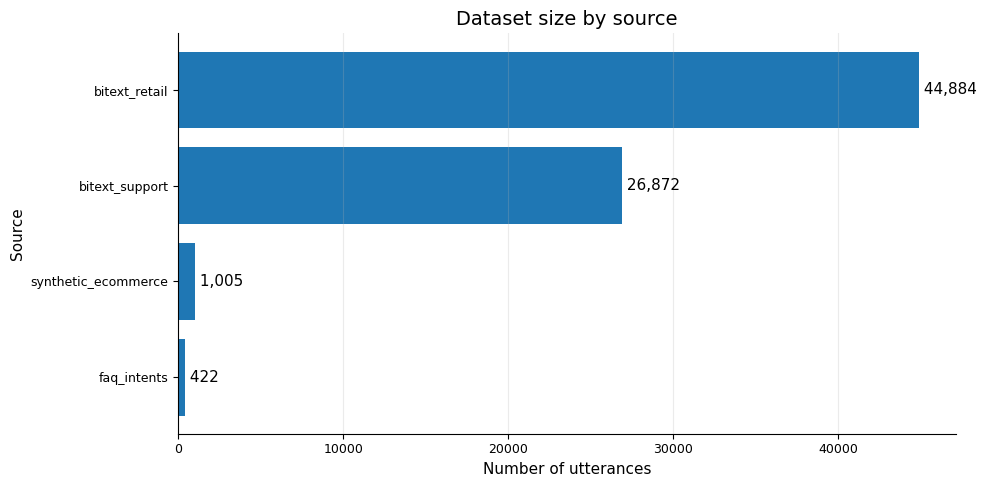

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = inventory_df.sort_values("rows")
ax.barh(plot_df["source"], plot_df["rows"])
ax.set_title("Dataset size by source")
ax.set_xlabel("Number of utterances")
ax.set_ylabel("Source")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
for i, v in enumerate(plot_df["rows"]):
    ax.text(v, i, f" {v:,}", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_dataset_size_by_source.png", dpi=200, bbox_inches="tight")
plt.show()

##  Intent and category distribution

In [7]:
category_source = (
    df_all.groupby(["source", "category"])
    .size()
    .reset_index(name="count")
    .sort_values(["source", "count"], ascending=[True, False])
)
category_source.to_csv(DATA_PROC / "01_category_distribution_by_source.csv", index=False)
category_source.head(20)

,source,category,count
9,bitext_retail,RETURNS,6925
8,bitext_retail,PRODUCT,6679
4,bitext_retail,DELIVERY,6595
0,bitext_retail,ACCOUNT,4950
6,bitext_retail,ORDER,3945
7,bitext_retail,PAYMENT,2981
5,bitext_retail,FEEDBACK,2980
1,bitext_retail,APP_WEBSITE,1993
3,bitext_retail,CONTACT,1986
2,bitext_retail,CART,1950


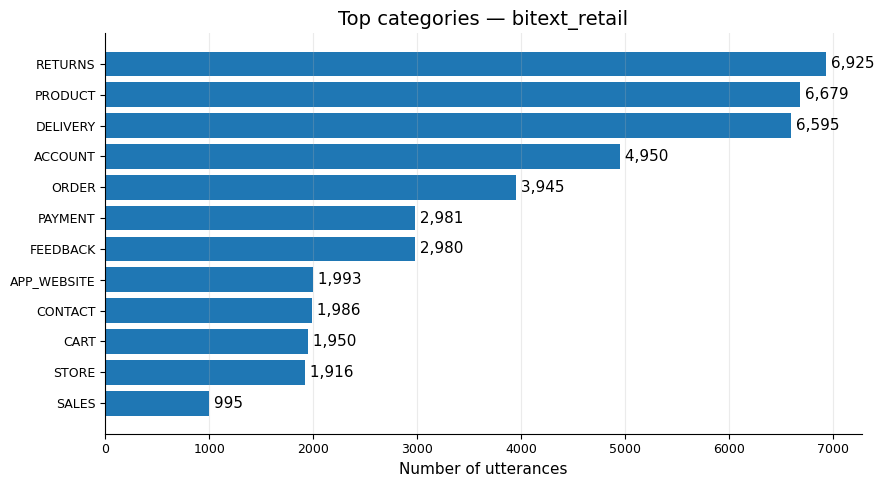

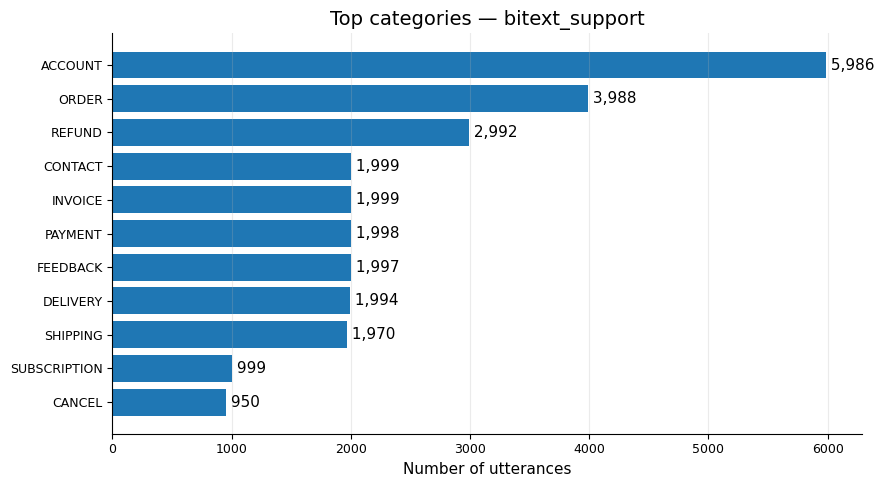

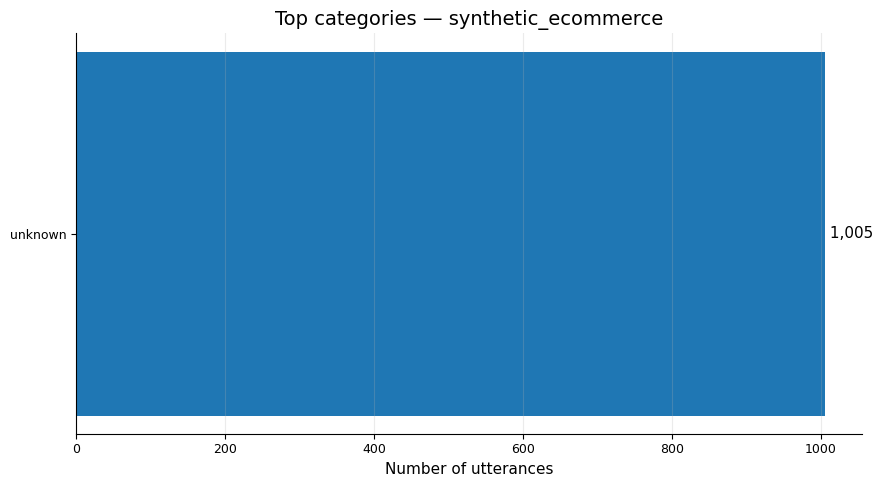

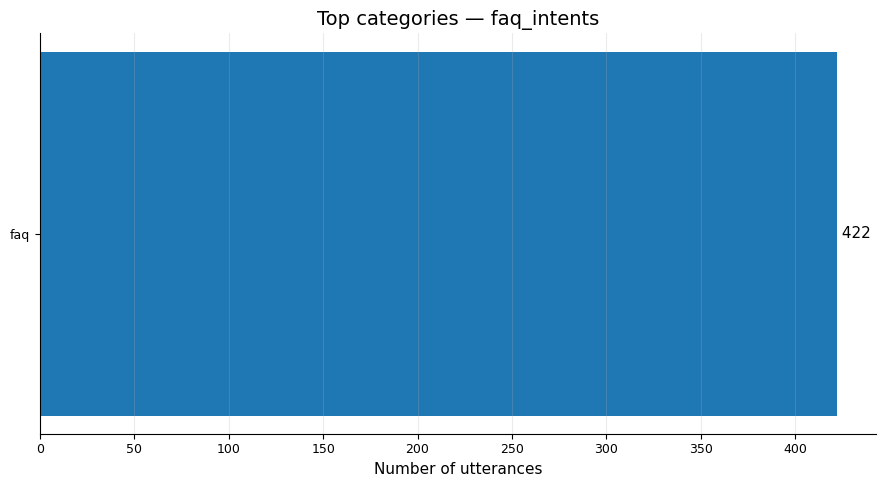

In [8]:
# Top categories per source
for source in df_all["source"].unique():
    sub = df_all[df_all["source"] == source]
    counts = sub["category"].value_counts().head(12).sort_values()
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(counts.index, counts.values)
    ax.set_title(f"Top categories — {source}")
    ax.set_xlabel("Number of utterances")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    for i, v in enumerate(counts.values):
        ax.text(v, i, f" {v:,}", va="center")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig_02_top_categories_{source}.png", dpi=200, bbox_inches="tight")
    plt.show()

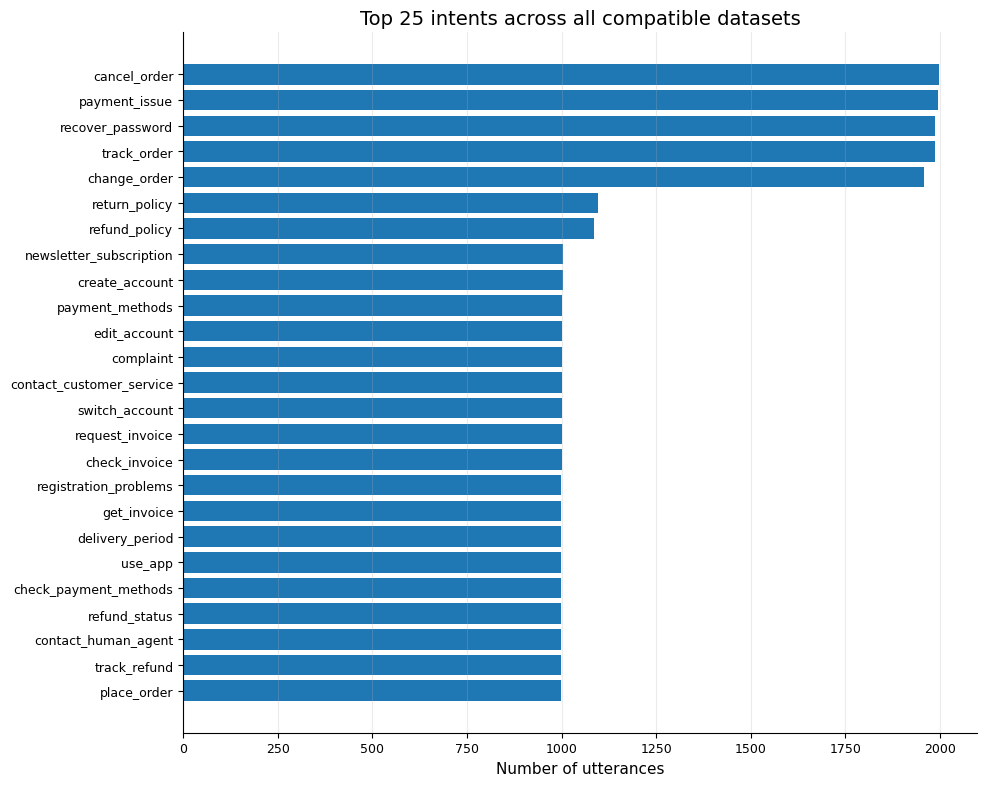

In [9]:
# Top intents globally
counts = df_all["intent"].value_counts().head(25).sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(counts.index, counts.values)
ax.set_title("Top 25 intents across all compatible datasets")
ax.set_xlabel("Number of utterances")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_top25_intents_global.png", dpi=200, bbox_inches="tight")
plt.show()

## Compatibility analysis with the main Bitext Retail reference

In [10]:
reference_source = "bitext_retail"
retail_intents = set(df_all.loc[df_all["source"] == reference_source, "intent"].dropna())

compat_rows = []
for source, g in df_all.groupby("source"):
    intents = set(g["intent"].dropna())
    shared = intents & retail_intents
    only_source = intents - retail_intents
    compat_rows.append({
        "source": source,
        "n_intents": len(intents),
        "shared_with_retail": len(shared),
        "unique_to_source": len(only_source),
        "shared_ratio_%": round(100 * len(shared) / max(len(intents), 1), 2),
        "decision": "main reference" if source == reference_source else (
            "directly compatible" if len(shared) / max(len(intents), 1) >= 0.5 else "requires filtering/mapping"
        )
    })

compat_df = pd.DataFrame(compat_rows).sort_values("shared_ratio_%", ascending=False)
compat_df.to_csv(DATA_PROC / "01_intent_compatibility_with_retail.csv", index=False)
compat_df

,source,n_intents,shared_with_retail,unique_to_source,shared_ratio_%,decision
0,bitext_retail,46,46,0,100.00,main reference
1,bitext_support,27,5,22,18.52,requires filtering/mapping
3,synthetic_ecommerce,14,2,12,14.29,requires filtering/mapping
2,faq_intents,97,5,92,5.15,requires filtering/mapping


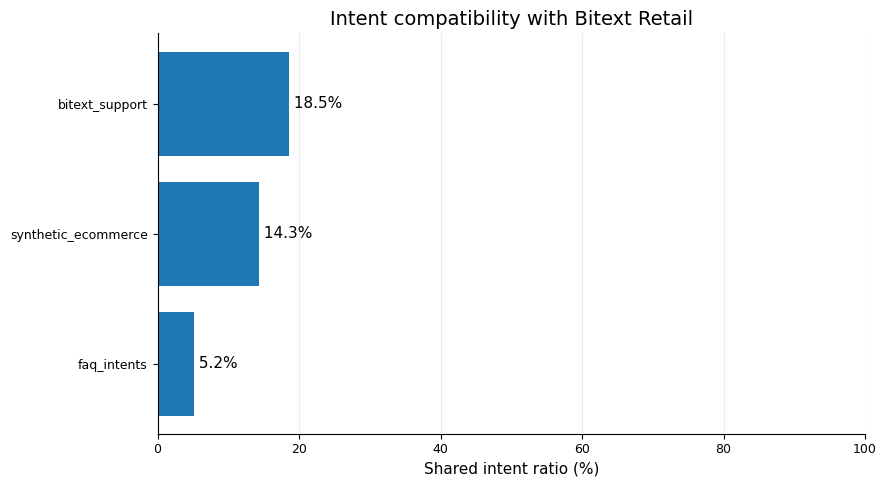

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = compat_df[compat_df["source"] != reference_source].sort_values("shared_ratio_%")
ax.barh(plot_df["source"], plot_df["shared_ratio_%"])
ax.set_title("Intent compatibility with Bitext Retail")
ax.set_xlabel("Shared intent ratio (%)")
ax.set_xlim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
for i, v in enumerate(plot_df["shared_ratio_%"]):
    ax.text(v, i, f" {v:.1f}%", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_intent_compatibility_with_retail.png", dpi=200, bbox_inches="tight")
plt.show()

##  Text length and linguistic variability

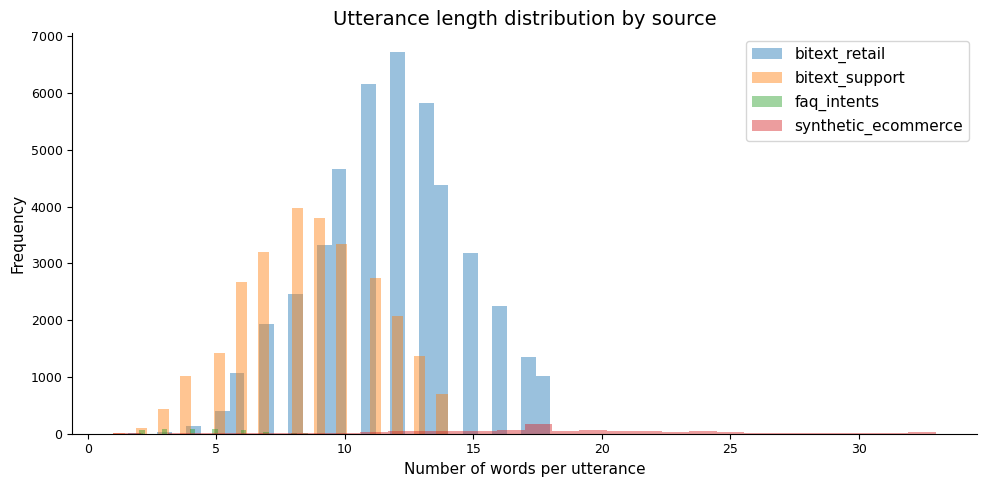

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for source, g in df_all.groupby("source"):
    clipped = g["text_len_words"].clip(upper=g["text_len_words"].quantile(0.98))
    ax.hist(clipped, bins=30, alpha=0.45, label=source)
ax.set_title("Utterance length distribution by source")
ax.set_xlabel("Number of words per utterance")
ax.set_ylabel("Frequency")
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_05_text_length_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
placeholder_df = (
    df_all.groupby("source")
    .agg(
        rows=("text", "size"),
        placeholder_rate=("has_placeholder", "mean"),
        avg_placeholder_count=("placeholder_count", "mean")
    )
    .reset_index()
)
placeholder_df["placeholder_rate_%"] = (100 * placeholder_df["placeholder_rate"]).round(2)
placeholder_df.to_csv(DATA_PROC / "01_placeholder_summary.csv", index=False)
placeholder_df

,source,rows,placeholder_rate,avg_placeholder_count,placeholder_rate_%
0,bitext_retail,44884,0.000000,0.000000,0.00
1,bitext_support,26872,0.248214,0.262057,24.82
2,faq_intents,422,0.000000,0.000000,0.00
3,synthetic_ecommerce,1005,0.000000,0.000000,0.00


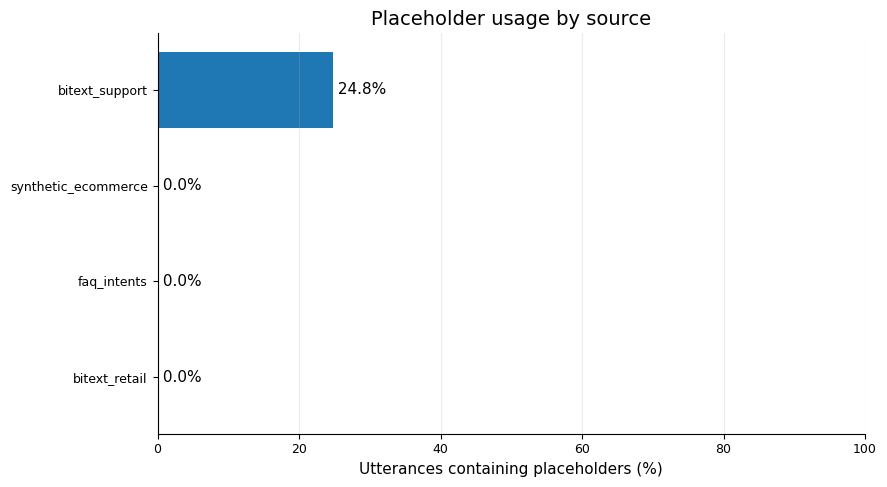

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = placeholder_df.sort_values("placeholder_rate_%")
ax.barh(plot_df["source"], plot_df["placeholder_rate_%"])
ax.set_title("Placeholder usage by source")
ax.set_xlabel("Utterances containing placeholders (%)")
ax.set_xlim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.25)
for i, v in enumerate(plot_df["placeholder_rate_%"]):
    ax.text(v, i, f" {v:.1f}%", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_06_placeholder_usage_by_source.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Amazon QA: high-confidence heuristic mapping only

In [15]:
# Amazon QA is not naturally an intent-classification dataset.
# Therefore, it must not be merged directly.
# It can only be used if questions are mapped to stable e-commerce intents with high-confidence rules.

AMAZON_RULES = {
    "product_information": [r"\b(size|dimension|weight|material|compatible|compatibility|fit|fits)\b"],
    "delivery_information": [r"\b(ship|shipping|delivery|arrive|arrival)\b"],
    "return_refund": [r"\b(return|refund|replace|replacement)\b"],
    "price_discount": [r"\b(price|discount|coupon|deal|sale)\b"],
}

def map_amazon_question(text: str) -> str | None:
    text = str(text).lower()
    matches = []
    for intent, patterns in AMAZON_RULES.items():
        if any(re.search(p, text) for p in patterns):
            matches.append(intent)
    # High-confidence condition: exactly one rule family matched
    return matches[0] if len(matches) == 1 else None

amazon_frames = []
for df, source in [(df_amazon_multi, "amazon_multi_questions"), (df_amazon_single, "amazon_single_qna")]:
    if not df.empty:
        q_col = find_first_existing_col(df, ["question", "questions", "text", "query"])
        a_col = find_first_existing_col(df, ["answer", "response"])
        if q_col:
            tmp = pd.DataFrame({
                "text": df[q_col].astype(str),
                "response": df[a_col].astype(str) if a_col else "",
                "source": source,
            })
            tmp["mapped_intent"] = tmp["text"].apply(map_amazon_question)
            amazon_frames.append(tmp)

amazon_mapped = pd.concat(amazon_frames, ignore_index=True) if amazon_frames else pd.DataFrame()
if not amazon_mapped.empty:
    amazon_summary = amazon_mapped["mapped_intent"].value_counts(dropna=False).rename_axis("mapped_intent").reset_index(name="count")
    amazon_mapped.to_csv(DATA_PROC / "01_amazon_high_confidence_mapping_preview.csv", index=False)
    display(amazon_summary)
else:
    print("Amazon QA files not loaded or no compatible question column found.")

Amazon QA files not loaded or no compatible question column found.
